In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
file_path = 'Station1_simulated_cleaned_merged_data.csv'
train_data = pd.read_csv(file_path)
#Set to Datetime
train_data['Date'] = pd.to_datetime(train_data['Date'])

<ipython-input-137-7c0d3d83becf>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  train_data['Date'] = pd.to_datetime(train_data['Date'])


In [ ]:
file_path = 'Station2_simulated_cleaned_merged_data.csv'
test_data = pd.read_csv(file_path)
#Set to Datetime
test_data['Date'] = pd.to_datetime(test_data['Date'])

<ipython-input-138-5cf78646334f>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  test_data['Date'] = pd.to_datetime(test_data['Date'])


In [ ]:
train_data['Sum_Rain_1h'] = train_data['Ppt'].rolling(window=1, min_periods=1).sum()
train_data['Sum_Rain_2h'] = train_data['Ppt'].rolling(window=2, min_periods=1).sum()
train_data['Sum_Rain_5h'] = train_data['Ppt'].rolling(window=5, min_periods=1).sum()
train_data['Sum_Rain_10h'] = train_data['Ppt'].rolling(window=10, min_periods=1).sum()
train_data['Sum_Rain_24h'] = train_data['Ppt'].rolling(window=24, min_periods=1).sum()

test_data['Sum_Rain_1h'] = test_data['Ppt'].rolling(window=1, min_periods=1).sum()
test_data['Sum_Rain_2h'] = test_data['Ppt'].rolling(window=2, min_periods=1).sum()
test_data['Sum_Rain_5h'] = test_data['Ppt'].rolling(window=5, min_periods=1).sum()
test_data['Sum_Rain_10h'] = test_data['Ppt'].rolling(window=10, min_periods=1).sum()
test_data['Sum_Rain_24h'] = test_data['Ppt'].rolling(window=24, min_periods=1).sum()

In [ ]:
#Shift data by 1 to not include current rain in window
train_data['Sum_Rain_1h_Shifted'] = train_data['Sum_Rain_1h'].shift(1)
train_data['Sum_Rain_2h_Shifted'] = train_data['Sum_Rain_2h'].shift(1)
train_data['Sum_Rain_5h_Shifted'] = train_data['Sum_Rain_5h'].shift(1)
train_data['Sum_Rain_10h_Shifted'] = train_data['Sum_Rain_10h'].shift(1)
train_data['Sum_Rain_24h_Shifted'] = train_data['Sum_Rain_24h'].shift(1)

test_data['Sum_Rain_1h_Shifted'] = test_data['Sum_Rain_1h'].shift(1)
test_data['Sum_Rain_2h_Shifted'] = test_data['Sum_Rain_2h'].shift(1)
test_data['Sum_Rain_5h_Shifted'] = test_data['Sum_Rain_5h'].shift(1)
test_data['Sum_Rain_10h_Shifted'] = test_data['Sum_Rain_10h'].shift(1)
test_data['Sum_Rain_24h_Shifted'] = test_data['Sum_Rain_24h'].shift(1)

In [ ]:

#Set predicted rain to the sum of shifted rain
train_data['Predicted_Rain_Next_Hour_1h'] = train_data['Sum_Rain_1h_Shifted']
train_data['Predicted_Rain_Next_Hour_2h'] = train_data['Sum_Rain_2h_Shifted']
train_data['Predicted_Rain_Next_Hour_5h'] = train_data['Sum_Rain_5h_Shifted']
train_data['Predicted_Rain_Next_Hour_10h'] = train_data['Sum_Rain_10h_Shifted']
train_data['Predicted_Rain_Next_Hour_24h'] = train_data['Sum_Rain_24h_Shifted']

#Set predicted rain to the sum of shifted rain
test_data['Predicted_Rain_Next_Hour_1h'] = test_data['Sum_Rain_1h_Shifted']
test_data['Predicted_Rain_Next_Hour_2h'] = test_data['Sum_Rain_2h_Shifted']
test_data['Predicted_Rain_Next_Hour_5h'] = test_data['Sum_Rain_5h_Shifted']
test_data['Predicted_Rain_Next_Hour_10h'] = test_data['Sum_Rain_10h_Shifted']
test_data['Predicted_Rain_Next_Hour_24h'] = test_data['Sum_Rain_24h_Shifted']

In [ ]:
#Cutoff first 48hours of data
cutoff_date = train_data['Date'].min() + pd.Timedelta(days=2)
train_data = train_data[train_data['Date'] >= cutoff_date]
#Cutoff first 48hours of data
cutoff_date = test_data['Date'].min() + pd.Timedelta(days=2)
test_data = test_data[test_data['Date'] >= cutoff_date]

In [ ]:
for hrs in [1, 24, 48, 72]: # 1hr, 1 day, 2 days, 3 days
    train_data[f'Ppt_{hrs}hr_later'] = train_data['Ppt'].shift(-hrs)
for hrs in [1, 24, 48, 72]: # 1hr, 1 day, 2 days, 3 days
    test_data[f'Ppt_{hrs}hr_later'] = test_data['Ppt'].shift(-hrs)

<ipython-input-143-3ced5bf8e894>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[f'Ppt_{hrs}hr_later'] = train_data['Ppt'].shift(-hrs)
<ipython-input-143-3ced5bf8e894>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data[f'Ppt_{hrs}hr_later'] = train_data['Ppt'].shift(-hrs)
<ipython-input-143-3ced5bf8e894>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentat

In [ ]:
train_data = train_data.dropna()

test_data = test_data.dropna()

In [ ]:
# Step 2: Data Preprocessing
# Extract seasonality features (e.g., month, day of week) from the date
train_data['Date'] = pd.to_datetime(train_data['Date'])
train_data['Month'] = train_data['Date'].dt.month
train_data['DayOfWeek'] = train_data['Date'].dt.dayofweek

test_data['Date'] = pd.to_datetime(test_data['Date'])
test_data['Month'] = test_data['Date'].dt.month
test_data['DayOfWeek'] = test_data['Date'].dt.dayofweek

In [ ]:
features = ['SWC_5', 'SWC_10', 'SWC_20', 'SWC_50', 'T_5', 'T_10', 'T_20', 'T_50', 'Tair', 'Srad', 'Latitude', 'Longitude', 'Month', 'DayOfWeek','Predicted_Rain_Next_Hour_1h','Predicted_Rain_Next_Hour_2h']
X_train = train_data[features]
y_train = train_data[['Ppt_1hr_later', 'Ppt_24hr_later', 'Ppt_48hr_later', 'Ppt_72hr_later', 'Ppt']]

X_test = test_data[features]
y_test = test_data[['Ppt','Ppt_1hr_later', 'Ppt_24hr_later', 'Ppt_48hr_later', 'Ppt_72hr_later']]


In [ ]:
na_counts = train_data.isna().sum()
print("NA counts per column:")
print(na_counts)

NA counts per column:
Date                            0
Ppt                             0
SWC_5                           0
SWC_10                          0
SWC_20                          0
SWC_50                          0
T_5                             0
T_10                            0
T_20                            0
T_50                            0
Ppt.1                           0
Tair                            0
RH                              0
Windspeed                       0
Winddirection                   0
Srad                            0
Latitude                        0
Longitude                       0
Sum_Rain_1h                     0
Sum_Rain_2h                     0
Sum_Rain_5h                     0
Sum_Rain_10h                    0
Sum_Rain_24h                    0
Sum_Rain_1h_Shifted             0
Sum_Rain_2h_Shifted             0
Sum_Rain_5h_Shifted             0
Sum_Rain_10h_Shifted            0
Sum_Rain_24h_Shifted            0
Predicted_Rain_Next_Hour_1

In [ ]:
rf_regressor = RandomForestRegressor()
rf_regressor.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
y_pred = rf_regressor.predict(X_test)

In [ ]:
test_data['Predicted_Rainfall_cur'] = y_pred[:, 0]
test_data['Predicted_Rainfall_1hr'] = y_pred[:, 1]
test_data['Predicted_Rainfall_1day'] = y_pred[:, 2]
test_data['Predicted_Rainfall_2day'] = y_pred[:, 3]
test_data['Predicted_Rainfall_3day'] = y_pred[:, 4]

In [ ]:
test_data['Predicted_Rainfall_1day'].head(50)

48    0.0075
49    0.0202
50    0.0076
51    0.5277
52    0.1337
53    0.0456
54    0.0456
55    0.0456
56    0.0481
57    0.0481
58    0.0659
59    0.0076
60    0.0025
61    0.0025
62    2.0930
63    0.0229
64    0.0229
65    0.0000
66    0.0025
67    0.0000
68    0.0051
69    0.0431
70    0.0431
71    0.0456
72    0.0608
73    0.0583
74    0.0583
75    0.0583
76    0.0583
77    0.0583
78    0.0583
79    0.0608
80    0.0583
81    0.0583
82    0.0583
83    0.0203
84    0.0203
85    0.0152
86    0.0152
87    0.0152
88    0.0152
89    0.0152
90    0.0583
91    0.0608
92    0.0583
93    0.0583
94    0.0583
95    0.0583
96    0.0431
97    0.0583
Name: Predicted_Rainfall_1day, dtype: float64

In [ ]:
train_data['Ppt'].head(50)

48    0.51
49    0.00
50    0.25
51    0.00
52    0.00
53    0.00
54    0.00
55    0.00
56    0.00
57    0.00
58    0.00
59    0.00
60    0.00
61    0.00
62    0.00
63    0.00
64    0.00
65    0.00
66    0.00
67    0.00
68    0.00
69    0.00
70    0.00
71    0.00
72    0.00
73    0.00
74    0.00
75    0.00
76    0.00
77    0.00
78    0.00
79    0.00
80    0.00
81    0.00
82    0.00
83    0.00
84    0.00
85    0.00
86    0.00
87    0.00
88    0.00
89    0.00
90    0.00
91    0.00
92    0.00
93    0.00
94    0.00
95    0.00
96    0.00
97    0.00
Name: Ppt, dtype: float64

In [ ]:
rmse_1hr = mean_squared_error(y_test['Ppt_1hr_later'], y_pred[:, 0], squared=False)
rmse_1d = mean_squared_error(y_test['Ppt_24hr_later'], y_pred[:, 1], squared=False)
rmse_2d = mean_squared_error(y_test['Ppt_48hr_later'], y_pred[:, 2], squared=False)
rmse_3d = mean_squared_error(y_test['Ppt_72hr_later'], y_pred[:, 3], squared=False)

# Output the performance
print(f"RMSE 1 hour: {rmse_1hr}")
print(f"RMSE 1 day: {rmse_1d}")
print(f"RMSE 2 days: {rmse_2d}")
print(f"RMSE 3 days: {rmse_3d}")

RMSE 1 hour: 1.4429106002375287
RMSE 1 day: 2.187228265783697
RMSE 2 days: 1.1442373037948967
RMSE 3 days: 1.1335170608494731


In [ ]:
print(f'MAE: {mae}')
print(f'RMSE: {rmse}')

MAE: 1.109815684987404
RMSE: 2.4412073179360863


In [ ]:
def calculate_rain_chance(ppt):
    # Expanded thresholds for finer granularity
    if ppt == 0:
        return 3  # 2% chance if no rain
    elif 0 < ppt <= 0.1:
        return 5  # 4% chance for very minimal rain
    elif 0.1 < ppt <= 0.2:
        return 8  # 5% chance
    elif 0.2 < ppt <= 0.3:
        return 10  # 6% chance
    elif 0.3 < ppt <= 0.5:
        return 15  # 10% chance for light rain
    elif 0.5 < ppt <= 0.7:
        return 20  # 20% chance
    elif 0.7 < ppt <= 1.0:
        return 30  # 30% chance for moderate rain
    elif 1.0 < ppt <= 1.5:
        return 40  # 40% chance
    elif 1.5 < ppt <= 2.0:
        return 50  # 50% chance for heavy rain
    elif 2.0 < ppt <= 2.5:
        return 60  # 60% chance
    elif 2.5 < ppt <= 3.0:
        return 70  # 70% chance for very heavy rain
    elif 3.0 < ppt <= 3.5:
        return 80  # 80% chance
    elif 3.5 < ppt <= 4.0:
        return 90  # 90% chance
    else:
        return 100  # 100% chance for extreme rain conditions


In [ ]:
# Define the standard deviation for the normally distributed error
std_dev = 0.5

# Add the normally distributed error to each prediction column
for column in ['Ppt','Predicted_Rainfall_cur','Predicted_Rainfall_1hr','Predicted_Rainfall_1day','Predicted_Rainfall_2day', 'Predicted_Rainfall_3day']:
    # Generate normally distributed errors
    error = np.random.normal(loc=0, scale=std_dev, size=len(test_data))

    # Apply the error and enforce a minimum value of 1%
    test_data[column] = test_data[column] + error
    test_data[column] = test_data[column].clip(lower=1)

# Ensure that the predictions do not exceed 100%
test_data[['Ppt','Predicted_Rainfall_cur','Predicted_Rainfall_1hr','Predicted_Rainfall_1day','Predicted_Rainfall_2day', 'Predicted_Rainfall_3day']] = test_data[['Ppt','Predicted_Rainfall_cur','Predicted_Rainfall_1hr','Predicted_Rainfall_1day','Predicted_Rainfall_2day', 'Predicted_Rainfall_3day']].clip(upper=100)

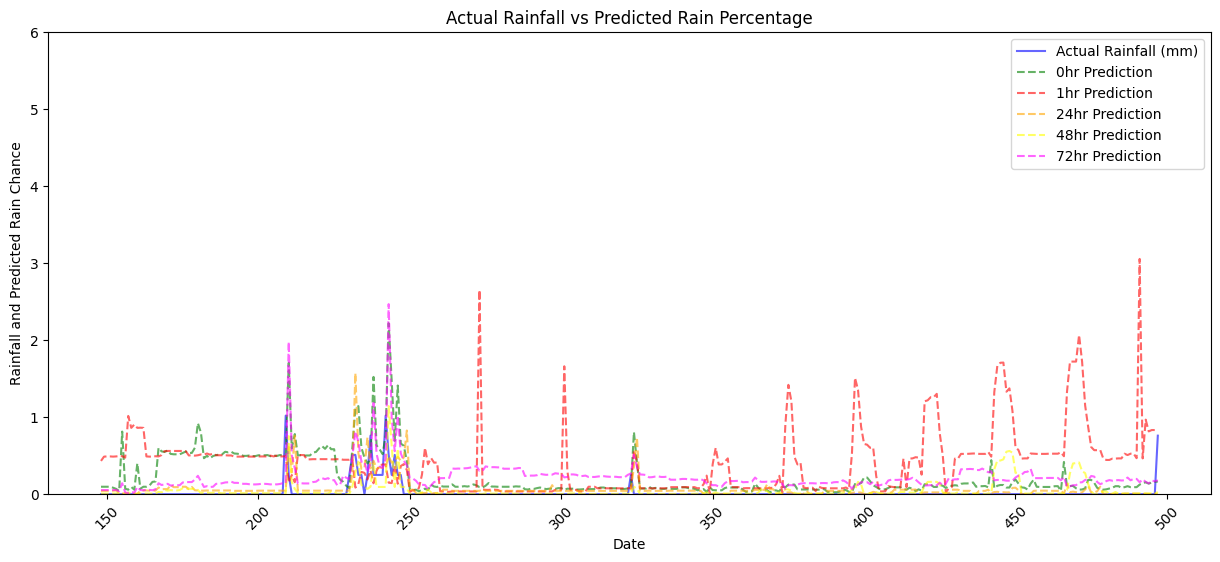

In [ ]:


data_chunk = test_data.iloc[100:450]
plt.figure(figsize=(15, 6))

# Plotting Actual Rainfall
plt.plot(data_chunk.index, data_chunk['Ppt'], label='Actual Rainfall (mm)', color='blue', alpha=0.6)

# Plotting Predicted Rain Chance Percentages
plt.plot(data_chunk.index, data_chunk['Predicted_Rainfall_cur'], label='0hr Prediction', color='green', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predicted_Rainfall_1hr'], label='1hr Prediction', color='red', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predicted_Rainfall_1day'], label='24hr Prediction', color='orange', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predicted_Rainfall_2day'], label='48hr Prediction', color='yellow', alpha=0.6, linestyle='--')
plt.plot(data_chunk.index, data_chunk['Predicted_Rainfall_3day'], label='72hr Prediction', color='magenta', alpha=0.6, linestyle='--')

# Setting labels and title
plt.xlabel('Date')
plt.ylabel('Rainfall and Predicted Rain Chance')
plt.title('Actual Rainfall vs Predicted Rain Percentage')

# Set y-axis limit from 0 to 1
plt.ylim([0, 6])

# Display legend
plt.legend()

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

plt.show()
